## Gradient Boosting - Core Intuition

- Gradient Boosting uses additive modeling to create model in which you take many weak models add them together in such a way that mistakes of previous model is fed to next model so that this next model do not make same errors we do this stagewise till certain numbers of iteration.

- We combine many weak learning models (High Bias but Low Variance) together to create one strong model (Low Bias and Low variance).

### How Random Forest trains trees
- For each tree in the forest, a new training dataset is created by randomly sampling the original dataset with replacement. Then at each node of a tree, instead of considering all available features to find the best split, the algorithm randomly selects a subset of features (e.g., the square root of the total number of features for classification). This forces each tree to consider different aspects of the data, increasing diversity among the trees and reducing their correlation.

- It is trained using Bootstrap Sampling and Feature Randomness.

### How Gradient Boosting trains trees
- First we create very simple model which is log-odd ( $ log( \frac{P(class A)}{P(class B)}) $ ) in classification and it will be mean of target values this will be our first model.

- As this log-odd is not the probability of the class we need to calculate probability and we will do that by using this formula ( $P=\frac{1}{1+e^{-(log-odd)}}$ ). Now that we have probability we can calculate pseudo-residual. 
- Now that we got residual we will train tree on that residual as target and all the features as input and this tree should be a regression tree and it should be a weak learner. Since we trained this tree on residual and that was probability we cannot add this probability to loss-odd to add result of this model to final prediction. we first calculate loss-odd at each leaf node of tree. Then add it to loss-odd of previous methods. we do this on multiple models then add them together while multiplying them with learning rate to make the difference in accuracy small and make model more accurate. 

### What problem boosting is trying to solve (bias or variance?)
- Since we are making trees which are weak learners they have Low variance but Very High bias. Boosting model is trying to decrease bias while maintaining variance at low.

### Boosting as Error Correction
- Models made after first simple model (often decision trees) are trained on all the features to predict errors made by combination of previous models which then is added to prediction to make prediction more accurate. In boosting trees is not trained on actual data but rather error of previous model.

## Baseline Comparison Setup

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("cleaned_data.csv", index_col="id")

In [2]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["default_payment_next_month"])
y = df["default_payment_next_month"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## Gradient Boosting Pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_feature = [
    "limit_bal", "age", "bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6", "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"
]

preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_feature)], remainder="passthrough" )

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

### Why no `class_weight` hear?
- Since we are calculating error and make training next model to predict those error to fix it buy adding the prediction of this error we don't need to tell model to explicitly look for class imbalance and correct it as it is already correcting it's mistake in next model.
### Why GB is more sensitive to noise than RF?
- Gradient boosting is more sensitive to noise than random forest due to its sequential, error-correcting training approach.  Each new tree in gradient boosting is built to correct the residuals (errors) of the previous ensemble, which means it focuses heavily on instances where the model performs poorly—often including noisy or outlier data points. This can cause the model to overfit to noise, as it treats misclassified or incorrectly predicted samples as important learning signals. 

- In contrast, random forests build trees independently on bootstrapped subsets of the data and use random feature selection, which introduces diversity and reduces the impact of any single noisy instance.  The final prediction is based on averaging (regression) or majority voting (classification), which smooths out the effect of noisy predictions from individual trees. 

## Cross Validation 

In [5]:
from sklearn.model_selection import cross_validate

scoring = ["accuracy", "precision", "recall", "roc_auc"]

gb_cv = cross_validate(gb_model, x_train, y_train, cv=5, scoring=scoring)

for metric in scoring:
    print(f"{metric} : ",gb_cv[f"test_{metric}"].mean())
    
gb_cv

accuracy :  0.8215835574795223
precision :  0.6789085028257853
recall :  0.3678363238667687
roc_auc :  0.7829213219630841


{'fit_time': array([7.77969623, 5.17024612, 5.13433981, 4.96367145, 5.00169134]),
 'score_time': array([0.02825785, 0.02385163, 0.01593566, 0.01586986, 0.01870227]),
 'test_accuracy': array([0.82961418, 0.81251303, 0.82186066, 0.81581143, 0.82811848]),
 'test_precision': array([0.70748299, 0.64310954, 0.67697595, 0.65033784, 0.7166362 ]),
 'test_recall': array([0.39208294, 0.34307257, 0.37169811, 0.36286522, 0.36946277]),
 'test_roc_auc': array([0.78886693, 0.77650139, 0.78007676, 0.78235472, 0.78680682])}

## Compare Against RF & LR

|Model                |ROC-AUC           |Recall            |Precision         |
|---------------------|------------------|------------------|------------------|
|Logistic Regression  |0.7253341012949435|0.6470579552931552|0.3814374524602476|
|Random Forest        |0.7686566649620062|0.3542594206248999|0.6615605274817108|
|Random Forest (Tuned)|0.7696328090333561|0.5580693815987934|0.5065023956194388|
|Gradient Boosting    |0.7829213219630841|0.3678363238667687|0.6789085028257853|

### Did Gradient Boosting improve ROC-AUC?
- Yes, ROC-AUC is even greater than ROC-AUC of Random forest after tuning which means that Gradient Boosting is very good at separating "default" from "Non-default". 

### Did recall improve meaningfully?
- No, though it increased slightly it is not enough to be considered meaningful.

### What trade-off got worse (if any)?
- Although GB has higher ROC-AUC than LR and RF but recall got worse which means GB is still not able to identify majority of "default" instances. which can be improved by threshold tuning.

## Test Set Evaluation

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

gb_model.fit(x_train, y_train)

y_pred = gb_model.predict(x_test)
y_prob = gb_model.predict_proba(x_test)[: ,1]

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("ROC-AUC : ", roc_auc_score(y_test,y_prob))
print("Confusion Matrix : \n", confusion_matrix(y_test, y_pred))

Accuracy :  0.8194560320373769
Precision :  0.6689750692520776
Recall :  0.36425339366515835
ROC-AUC :  0.7726305748684402
Confusion Matrix : 
 [[4428  239]
 [ 843  483]]


## Gradient Boosting — Reviewer Interpretation

### Is GB better than RF here?
-  No but it can be better because according GB's ROC-AUC which is used to compare two models is marginally than RF but it's recall is very low so we cannot say GB is better but after fine tuning to increase it's recall it can be better.

### Is the improvement consistent or marginal?
- Yes, improvement is consistent as we have checked it using cross validation but it is still marginal. As GB's ROC-AUC is 0.78 while RF's ROC-AUC is 0.76.

### Does GB justify increased sensitivity and complexity?
- In it's current form gradient booting's complexity is not justified as it's recall is very low but it can be after some fine tuning to increase it's recall which leads to direct loss to business.

### What kind of data would GB struggle with?
- GB will struggle with data with very noisy data as model try to correct them sequentially it may overfit that noise and perform poorly.

## Why Gradient Boosting Uses Shallow Trees

- Because shallow tree provides low variance but high bias which is in our favour because algorithm reduced bias by incrementally adding many such trees while keeping variance low.

### What happens if trees are very deep?
- In gradient boosting, trees are trained sequentially on residual errors. If trees are very deep, they aggressively fit these residuals, including noise. Because each tree depends on the previous one, this overcorrection propagates through the ensemble, increasing variance and harming generalization.

### Why boosting prefers weak learners
- Boosting prefers weak learners because they cannot fully fit the data in a single step. This forces the model to learn incrementally, where each learner corrects specific errors made by previous learners, leading to controlled bias reduction without excessive variance.

### How shallow trees reduce overfitting
- Because shallow tree cannot fit to data well due to less complex set of rules so they are resistant to overfitting.

## Learning Rate as Step Size

- We add prediction made by first simple model with error prediction made by other models but we also multiply it by learning rate which is same for all the model after first simple model. We do not multiply first models prediction with learning rate as it is actual prediction and not error of previous model.

- Now, we do this because we don't want to make very large jump in error correction because it might jump the actual prediction and in general we want to take small steps in correcting our model as we do in linear regression in gradient descent to find optimal line which fits data. That is why learning rate is considered as step size as it determines weightage of every model except first simple model.

- So, if learning rate is high model take aggressive steps to correct error. It might get past optimal values and had to make another correction and in general this is very unstable while if learning rate is low model takes slow and steady steps to correct it's mistakes which more stable.  

## Controlled Experiments

### Varying Tree Depth

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

depths = [1, 3, 5]

for d in depths:
    
    gb = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", GradientBoostingClassifier(random_state=42, max_depth=d))
        ]
    )
    
    score = cross_validate(gb, x_train, y_train, cv=5, scoring="roc_auc")
    
    print(f"Depth : {d} - ROC-AUC Score : {score['test_score'].mean():.4f}")

Depth : 1 - ROC-AUC Score : 0.7744
Depth : 3 - ROC-AUC Score : 0.7829
Depth : 5 - ROC-AUC Score : 0.7814


#### Which depth worked best?
- Depth of 3 worked best this again proves that GB works best with small trees or weak learning trees.

#### Why very deep trees hurt GB?
- Very deeps trees reduce error using complex rules which results in overfitting the data or noise in the data which leads to poor performance on unseen data.

#### How this differs from Random Forest
- We use deep trees which are trained on subset of features in Random Forest because it provides low bias but high variance but in case of random forest we reduce variance by averaging prediction of multiple trees. 

### Varying Learning Rate

In [8]:
rates = [0.1, 0.05, 0.01]

for rate in rates:
    
    gb = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", GradientBoostingClassifier(random_state=42, learning_rate=rate))
        ]
    )
    
    score = cross_validate(gb, x_train, y_train, cv=5, scoring="roc_auc")
    
    print(f"Rate : {rate} - ROC-AUC : {score['test_score'].mean():.4f}")

Rate : 0.1 - ROC-AUC : 0.7829
Rate : 0.05 - ROC-AUC : 0.7810
Rate : 0.01 - ROC-AUC : 0.7693


- The learning rate experiment shows that a value of 0.1 achieves the highest ROC-AUC, with 0.05 performing nearly as well. This suggests that the model is not overly sensitive to moderate learning rates on this dataset. When the learning rate is reduced to 0.01, performance drops, indicating underfitting due to insufficient model capacity given the fixed number of estimators. This confirms the expected trade-off where lower learning rates require more trees to achieve comparable bias reduction.

#### Why smaller learning rate is usually safer and Why low LR often needs more trees?
- Because with small learning rates we are taking small steps towards optimal values which is generally better but you have to also consider number of estimator you are using as low learning rate means low weightage of each model we naturally need more number of models to compensate for that else bias will be high as we use shallow trees to get lower variance and maintain/reduce bias by adding other models sequentially.

#### Why this trade-off exists?
- This trade-off exists due to low weightage of each model thus reducing error correction of every models so we need more models to reduce error.

## Bias–Variance Control in Gradient Boosting

### Which parameter controls bias most?
- Number of trees in model matters most to control bias as Gradient Boosting use shallow trees to get lower variance and control bias by adding other models sequentially. The number of trees also helps reduce bias only in combination with an appropriate learning rate.

### Which controls variance most?
- Learning rate of model matter most to control variance. if learning rate is low then model is less likely to overfit due to low weightage of each model in our final model and to maintain it's performance we also need to increase number of trees in model. with low learning rate and high model count model generalize to data better thus decreasing variance. Tree depth and subsampling also play an important role in controlling variance.

### Why GB is more sensitive to noisy labels?
- Gradient Boosting works by fixing error made by previous model by adding models sequentially but if we have noise in the data it will show up in error too then model will try to correct it and will overfit that noise this decreased performance overall.

## When Gradient Boosting Is the Right Choice

### What type of data benefits most from GB?
- Structured/Tabular data benefits most from gradient boosting especially where their is mix of numeric and categorical data. Also when data has complex, non-linear relationship.

### When would you prefer Random Forest instead?
- Random Forest is preferred over Gradient Boosting :
    - When we have limited time for hyperparameter tuning as it provides good performance out-of-the=box.
    - When we have lot of noise in our data as Random Forest is less prone to overfitting noises in the data.
    - Training is faster makes it suitable for large dataset.
    - We also use Random Forest as baseline model for evaluating other models performance.
    - Also when we need to check which feature is more important as it provides straightforward feature importance score.

## Final Model Review

In [9]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42, max_depth=3, learning_rate=0.1))
    ]
)

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

gb_model.fit(x_train, y_train)

y_pred = gb_model.predict(x_test)
y_prob = gb_model.predict_proba(x_test)[: ,1]

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("ROC-AUC : ", roc_auc_score(y_test,y_prob))
print("Confusion Matrix : \n", confusion_matrix(y_test, y_pred))

Accuracy :  0.8194560320373769
Precision :  0.6689750692520776
Recall :  0.36425339366515835
ROC-AUC :  0.7726305748684402
Confusion Matrix : 
 [[4428  239]
 [ 843  483]]


Text(0.5, 1.0, 'Gradient Boosting | Confusion Matrix')

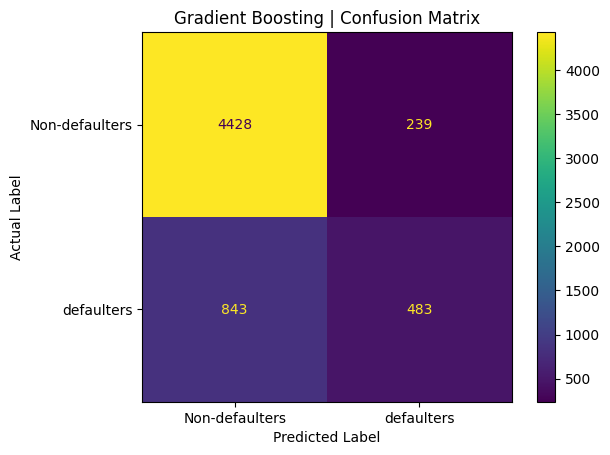

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-defaulters", "defaulters"])

ax = plt.subplot()

plot.plot(ax=ax)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Gradient Boosting | Confusion Matrix")